# FreeSurfer 2: group comparison analysis based on effect size

We have a series of notebooks to demonstrate some standard analyses with FreeSurfer.  
This notebooks shows how to run a simple group comparison colocalization analysis.

The data was prepared in the [data preparation notebook](freesurfer_1_prepare.ipynb).

In [20]:
# general imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# monkey patch to make progress bars show as ASCII instead of as widgets
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm
tqdm = tqdm.notebook.tqdm

In [21]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

## Load data

We prepared the data before and will only load the baseline data for the CB and HC groups

In [22]:
# cortical thickness data
df_cortex = pd.read_csv(Path.cwd() / "freesurfer_ct_baseline.csv", index_col=0)

# subcortical volume data
df_subcortex = pd.read_csv(Path.cwd() / "freesurfer_sc_baseline.csv", index_col=0)

# covariates
df_covariates = pd.read_csv(Path.cwd() / "freesurfer_cov_baseline.csv", index_col=0)

# participants df
df_participants = pd.read_csv(Path.cwd() / "freesurfer_participants.csv", index_col=0)
# subset to available subjects
df_participants = df_participants.loc[df_cortex.index]

## Group comparison


This would be the default FreeSurfer analysis in a very easy fashion. We'll perform a t-test for each parcel to check if there are significant differences between the two groups or time points.

In [23]:
from scipy.stats import ttest_ind

# ------------------------------------------------------------------------------------
# Between-groups 
# run t-test for each parcel
res_ttest = ttest_ind(
    df_cortex[df_participants.group == "CB"],
    df_cortex[df_participants.group == "HC"],
    axis=0
)

# put the output into a dataframe
df_ttest = pd.DataFrame(
    {   
        "mean_case": df_cortex[df_participants.group == "CB"].mean().values,
        "mean_control": df_cortex[df_participants.group == "HC"].mean().values,
        "Tvalue": res_ttest.statistic,
        "pvalue": res_ttest.pvalue,
        "df": res_ttest.df,
        "hemi": ["L" if l.startswith("lh_") else "R" for l in df_cortex.columns]
    }, 
    index=df_cortex.columns
)

# print the results sorted by p value
print("Results sorted by p value:")
df_ttest.sort_values("pvalue").head(50)


Results sorted by p value:


,mean_case,mean_control,Tvalue,pvalue,df,hemi
rh_lateralorbitofrontal_thickness,2.502316,2.631667,-3.399717,0.001598,38.0,R
lh_temporalpole_thickness,3.414158,3.623000,-2.107948,0.041687,38.0,L
rh_parsopercularis_thickness,2.661316,2.741476,-1.897322,0.065404,38.0,R
rh_rostralanteriorcingulate_thickness,2.691947,2.811619,-1.736240,0.090624,38.0,R
rh_postcentral_thickness,1.991579,2.063667,-1.703158,0.096705,38.0,R
rh_precentral_thickness,2.529526,2.589381,-1.651401,0.106898,38.0,R
lh_insula_thickness,2.999105,3.054190,-1.587344,0.120722,38.0,L
rh_entorhinal_thickness,3.067421,3.178571,-1.586874,0.120829,38.0,R
rh_rostralmiddlefrontal_thickness,2.234737,2.286952,-1.578308,0.122784,38.0,R
rh_parstriangularis_thickness,2.458737,2.531000,-1.558729,0.127351,38.0,R


We have a simple function ready to inspect the results in a 3D viewer for one hemisphere. 

We can observe a tendency towards increased cortical thickness in specific brain areas. Our colocalization analysis will now serve to find a pattern in the reference data that is most correlated with the observed pattern in the sample data. This could give us insights into potential mechanisms that could have led to the observed alteration pattern.

In [24]:
from nispace.plotting import view_surf

# plot
view_surf(df_ttest.loc[df_ttest.hemi == "L", "Tvalue"], parcellation="Desikan", template="fsaverage", hemi="L")

INFO | 23/04/26 15:34:39 | nispace: Loading cortex parcellation 'DesikanKilliany' in 'fsaverage' space.


## Perform colocalization with cortical thickness data

Finally! After all this data-wrangling, we can perform our main analysis.

### Fetch reference data

First, we will fetch our "reference data" for both parcellations.  
In NiSpace, as "reference data", we refer to the data that you would like to compare your sample data to. In the related JuSpace toolbox, this might often be a set of PET maps from different tracers.

We will go with that and load the standard set of PET maps, one per tracer for a set of unique targets.
NiSpace ships both the imaging maps themselves but also pre-computed parcellated data. The latter can be fetched by passing a parcellation to the `fetch_reference` function.

In [25]:
from nispace.datasets import fetch_reference

# Load reference data in Desikan-Killiany (alternative: Destrieux) parcellation
df_reference = fetch_reference(
    "pet", 
    collection="UniqueTracers", 
    parcellation="Desikan",
    print_references=True, # we can suppress printing the list of references here
)

print("Shape of reference data:", df_reference.shape)

INFO | 23/04/26 15:34:39 | nispace: Loading pet maps.
INFO | 23/04/26 15:34:39 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 23/04/26 15:34:39 | nispace: Filtering maps by collection.
INFO | 23/04/26 15:34:39 | nispace: Loading data parcellated with 'DesikanKilliany'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fsLR"), 
they are downloaded from the NiSpace-data GitHub repo (find them in `~HOME/nispace-data/reference/pet/map`). 
The NiSpace-hosted MNI maps were directly registered to 2mm MNI152NLin6Asym space, and transformed to 2m

When working with parcellated data, it always makes sense to check if the parcel order aligns between different datasets. We'll print the columns of the sample and reference data to check if they align.

Here, you can see that the columns of the sample data and reference data align, even though they have different naming schemes.


In [26]:
print("Columns of Destrieux sample and reference data:")
display(pd.DataFrame({"Sample": df_cortex.columns, "Reference": df_reference.columns}))

Columns of Destrieux sample and reference data:


,Sample,Reference
0,lh_bankssts_thickness,hemi-L_lab-bankssts
1,lh_caudalanteriorcingulate_thickness,hemi-L_lab-caudalanteriorcingulate
2,lh_caudalmiddlefrontal_thickness,hemi-L_lab-caudalmiddlefrontal
3,lh_cuneus_thickness,hemi-L_lab-cuneus
4,lh_entorhinal_thickness,hemi-L_lab-entorhinal
...,...,...
63,rh_supramarginal_thickness,hemi-R_lab-supramarginal
64,rh_frontalpole_thickness,hemi-R_lab-frontalpole
65,rh_temporalpole_thickness,hemi-R_lab-temporalpole
66,rh_transversetemporal_thickness,hemi-R_lab-transversetemporal


### Simple group comparison

We'll run a simple group comparison based on effect size difference maps. This will do the following:
1. it will take the sample data and calculate, for each parcel, the effect size difference between the two groups
2. it will correlate the effect size difference maps with the reference data across parcels, separately for each reference map
3. it will calculate exact p values for each correlation coefficient by permuting the groups and re-running steps 1 and 2

The function performs a whole workflow in one go and outputs an overview plot of the "design matrix" and the results.
Minimum input are the reference and sample data, the name of the parcellation (or surface files), and a 0/1 vector indicating group memberships.

subject
sub-101    a
sub-103    a
sub-104    a
sub-108    a
sub-109    a
Name: group, dtype: object

,groups,age,sex,euler_number,eTIV
subject,,,,,
sub-101,a,24.44,male,16.0,1.562223e+06
sub-103,a,24.33,male,42.0,1.692744e+06
sub-104,a,17.90,female,35.0,1.384595e+06
sub-108,a,19.39,male,53.0,1.661247e+06
sub-109,a,20.38,male,23.0,1.621123e+06


INFO | 23/04/26 15:34:39 | nispace: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 23/04/26 15:34:39 | nispace: Building multi-space Parcellation for 'DesikanKilliany' from library.
INFO | 23/04/26 15:34:39 | nispace: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/04/26 15:34:39 | nispace: Parcellation 'DesikanKilliany' available in spaces: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym', 'fsaverage', 'fsLR'].
INFO | 23/04/26 15:34:39 | nispace: Parcellation 'DesikanKilliany': validation passed.
INFO | 23/04/26 15:34:39 | nispace: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 23/04/26 15:34:40 | nispace: Parcellation 'DesikanKilliany': active space set to 'MNI152NLin2009cAsym'.
INFO | 23/04/26 15:34:40 | nispace: Checking input data for 'x' (should be, e.g., PET data):
INFO | 23/04/26 15:34:40 | nispace: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 23/04/2

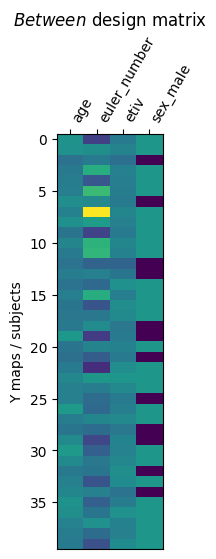

INFO | 23/04/26 15:34:40 | nispace: Protecting 1 variable(s) during regression: ['groups_b'].
INFO | 23/04/26 15:34:40 | nispace: Regressing 4 between covariate(s) from Y.


Regressing 4 between covariate(s) from Y, protecting 1 variable(s) (-1 proc): 100%|██████████| 68/68 [00:00<00:00, 2268.58it/s]

INFO | 23/04/26 15:34:40 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 23/04/26 15:34:40 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 23/04/26 15:34:40 | nispace: Applying Y transform 'hedges(a,b)'.
INFO | 23/04/26 15:34:40 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 23/04/26 15:34:40 | nispace: Running 'spearman' colocalization with 'hedges(a,b)' transform.
INFO | 23/04/26 15:34:40 | nispace: Pre-ranking X and Y data.



Colocalizing (spearman, -1 proc): 100%|██████████| 1/1 [00:00<00:00, 1311.95it/s]

INFO | 23/04/26 15:34:40 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 23/04/26 15:34:40 | nispace: Permutation of: Y groups.
INFO | 23/04/26 15:34:40 | nispace: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').
INFO | 23/04/26 15:34:40 | nispace: Loading transformed Y data, transform = 'hedges(a,b)'.
INFO | 23/04/26 15:34:40 | nispace: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 23/04/26 15:34:40 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 23/04/26 15:34:40 | nispace: Generating permuted Y groups.
INFO | 23/04/26 15:34:40 | nispace: Permuting groups/sessions vector, strategy: unpaired, proportional.



Null transformations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:00<00:00, 31782.54it/s]


INFO | 23/04/26 15:34:41 | nispace: Pre-ranking X and Y (null) data.


Null colocalizations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:00<00:00, 34158.24it/s]


INFO | 23/04/26 15:34:42 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 23/04/26 15:34:42 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 23/04/26 15:34:42 | nispace: Correction method: 'meff_galwey', alpha: 0.05, dimension: 'array'.
INFO | 23/04/26 15:34:42 | nispace: Meff_X (galwey) = 10.48 (from 29 maps).
INFO | 23/04/26 15:34:42 | nispace: *** NiSpace.normalize_colocalizations() - Normalize colocalizations against null distribution. ***
INFO | 23/04/26 15:34:42 | nispace: Z-score method: robust (median/MAD).
INFO | 23/04/26 15:34:42 | nispace: Stored normalized colocalizations: xdimred-false_ytrans-hedges(a,b)_coloc-spearman_stat-rho_xsea-false_perm-groups
INFO | 23/04/26 15:34:42 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/04/26 15:34:43 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 23/04/26 15:34:43 | nispace: Significance annotation: 0/29 

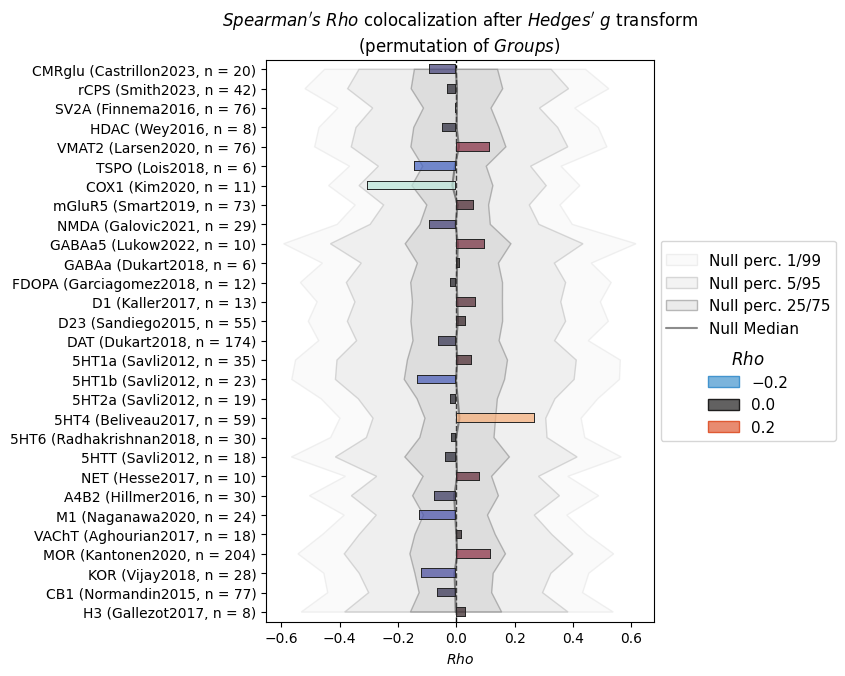

INFO | 23/04/26 15:34:44 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 
INFO | 23/04/26 15:34:44 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 
INFO | 23/04/26 15:34:44 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | meffgalwey | False       | hedges(a,b) | 


In [27]:
from nispace.workflows import group_comparison

# we could pass this as the "design" argument. in the simplest case, this is a 0/1 vector indicating group memberships
design = df_participants.group.map({"CB":"a", "HC":"b"})
display(design.head(5))

# instead of only the groups vector, we can also pass covariates as in a GLM's design matrix
# only the variable "groups" is required, every other covariate is optional and will be regressed out
# of each parcel's data across subjects before the colocalization analysis
# we can do paired analyses by passing a "subjects" + the "groups" vector (then, e.g., timepoints).
design = pd.DataFrame({
    "groups": df_participants.group.map({"CB":"a", "HC":"b"}), 
    "age": df_participants["age at baseline "], 
    "sex": df_participants["gender"],
    "euler_number": df_covariates["SurfaceHoles"],
    "eTIV": df_covariates["EstimatedTotalIntraCranialVol"]
})
display(design.head(5))

# run
colocs, pvalues, qvalues, nsp_object = group_comparison(
    y=df_cortex, # sample data
    x=df_reference, # reference data
    parcellation="Desikan", # parcellation
    design=design, # group membership
    comparison_method="hedges(a,b)", # effect size 
    colocalization_method="spearman", # spearman correlation btw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=True,
    seed=42,
    
)

The outputs of the workflow function are:
- `colocs`: the correlation coefficients between the effect size maps and the reference data across parcels
- `pvalues`: the p values for each correlation coefficient
- `qvalues`: the FDR-corrected p values for each correlation coefficient
- `nsp_object`: the NiSpace object, which contains the results and can be used for further analyses  

We will print the first three dataframes:

In [28]:
display("Colocalization:", colocs)
display("p values:", pvalues)
display("q values:", qvalues)

'Colocalization:'

set                                                   General  \
map    target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
hedges                                           -0.09395       

set                                                         \
map    target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
hedges                                          -0.031732    

set                                                        \
map    target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
hedges                                          -0.006451   

set                                                          \
map    target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
hedges                                          -0.048134     

set                                                        \
map    target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
hedges                                           0.113861   

set                                           Immunity  \
map    target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
hedges                                       -0.146709   

set                                                    \
map    target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
hedges                                      -0.305368   

set                                               Glutamate  \
map    target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
hedges                                           0.059428     

set                                                         \
map    target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
hedges                                          -0.092834    

set                                                      GABA  ...  \
map    target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
hedges                                           0.098265      ...   

set                                                        Serotonin  \
map    target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
hedges                                          -0.017408              

set                                                      \
map    target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
hedges                                        -0.038458   

set                       Noradrenaline/Acetylcholine  \
map    target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
hedges                                       0.082294   

set                                                             \
map    target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
hedges                                          -0.078106        

set                                                             \
map    target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
hedges                                          -0.127572        

set                                                            \
map    target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
hedges                                           0.020463       

set                                       Opiods/Endocannabinoids  \
map    target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
hedges                                           0.117918           

set                                                          \
map    target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
hedges                                          -0.119937     

set                                                         \
map    target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
hedges                                          -0.066288    

set                                                Histamine  
map    target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
hedges                                           0.033375     

[1 rows x 29 columns]

'p values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                             0.6614       

set                                                       \
map  target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
mean                                             0.8852    

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
mean                                             0.9566   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                              0.826     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                             0.6502   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                          0.3882   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                           0.14   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                              0.723     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                             0.6118    

set                                                    GABA  ...  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
mean                                              0.732      ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                             0.9276              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                            0.892   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                          0.649   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                             0.7358        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                             0.4474        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                             0.9154       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                              0.641           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                              0.572     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                             0.7338    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                              0.884     

[1 rows x 29 columns]

'q values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                           0.999988       

set                                                       \
map  target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
mean                                                1.0    

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
mean                                                1.0   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                                1.0     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                           0.999983   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                        0.994209   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                       0.794287   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                           0.999999     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                           0.999951    

set                                                    GABA  ...  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
mean                                           0.999999      ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                                1.0              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                              1.0   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                       0.999983   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                           0.999999        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                           0.998008        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                                1.0       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                           0.999978           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                           0.999863     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                           0.999999    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                                1.0     

[1 rows x 29 columns]

There we go! There aren't too many significant results and nothing survives FDR correction. 

In [29]:
pvalues.T["mean"].sort_values().head(6)

set                          map                                                    
Immunity                     target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020             0.1400
Serotonin                    target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beliveau2017    0.1574
Immunity                     target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018            0.3882
Noradrenaline/Acetylcholine  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020    0.4474
Opiods/Endocannabinoids      target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018       0.5720
Serotonin                    target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012          0.6110
Name: mean, dtype: float32

And this would be what the correlation itself looks like for a single reference map:

INFO | 23/04/26 15:34:44 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


Text(0.5, 1.0, "Correlation between Hedges' g and reference map density across parcels")

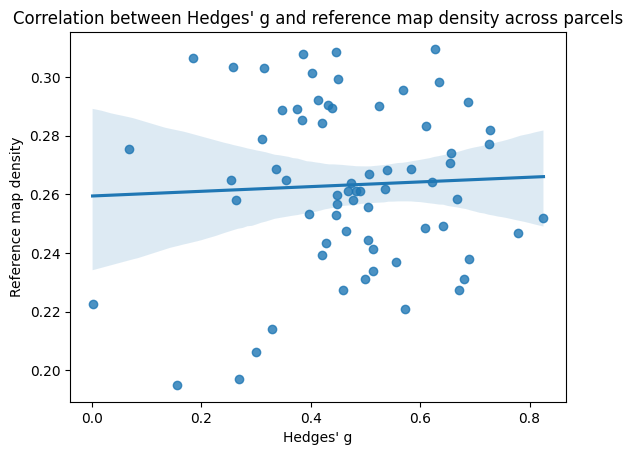

In [30]:
import matplotlib.pyplot as plt
from seaborn import regplot

regplot(
    x=nsp_object.get_y(Y_transform="hedges(a,b)").loc["hedges"],
    y=df_reference.loc[('Noradrenaline/Acetylcholine', 'target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016')],
)
plt.xlabel("Hedges' g")
plt.ylabel("Reference map density")
plt.title("Correlation between Hedges' g and reference map density across parcels")


## Perform colocalization with cortical thickness and subcortical data

### Prepare data

We'll do the same as above. However, we have to  
(1) fetch reference data for DesikanKilliany as well as the FreeSurfer subcortical "Aseg" parcellation and  
(2) combine the cortical thickness and subcortical volume data

IMPORTANT NOTE:  
combining data from two different modalities (i.e.: thickness vs. volume) is only reasonable when the actual colocalization analysis is performed on a standardized outcome (e.g., effect size, beta value, z score).

In [31]:
# input data: combine cortex and subcortex
df_cortexsubcortex = pd.concat([df_cortex, df_subcortex], axis=1)

# reference data: we can fetch this as above but passing "DesikanAseg" as parcellation to the argument.
# However, that is not necessary as NiSpace can generally fetch the data directly throught the workflow function.

### Simple group comparison

We'll do the same as above.

INFO | 23/04/26 15:34:44 | nispace: Loading integrated pet dataset as X data.
INFO | 23/04/26 15:34:44 | nispace: Using collection UniqueTracers.
INFO | 23/04/26 15:34:44 | nispace: Loading pet maps.
INFO | 23/04/26 15:34:44 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 23/04/26 15:34:44 | nispace: Filtering maps by collection.
INFO | 23/04/26 15:34:44 | nispace: Loading and inner-merging data parcellated with 'DesikanKilliany' and 'Aseg'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fsLR"), 
they are downloaded from the NiSpace-da

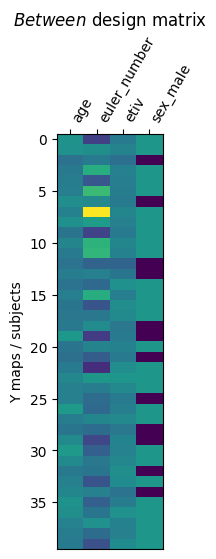

INFO | 23/04/26 15:34:45 | nispace: Protecting 1 variable(s) during regression: ['groups_b'].
INFO | 23/04/26 15:34:45 | nispace: Regressing 4 between covariate(s) from Y.


Regressing 4 between covariate(s) from Y, protecting 1 variable(s) (-1 proc): 100%|██████████| 84/84 [00:00<00:00, 2192.12it/s]

INFO | 23/04/26 15:34:45 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 23/04/26 15:34:45 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 23/04/26 15:34:45 | nispace: Applying Y transform 'hedges(a,b)'.
INFO | 23/04/26 15:34:45 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 23/04/26 15:34:45 | nispace: Running 'spearman' colocalization with 'hedges(a,b)' transform.
INFO | 23/04/26 15:34:45 | nispace: Pre-ranking X and Y data.



Colocalizing (spearman, -1 proc): 100%|██████████| 1/1 [00:00<00:00, 2257.43it/s]

INFO | 23/04/26 15:34:45 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 23/04/26 15:34:45 | nispace: Permutation of: Y groups.
INFO | 23/04/26 15:34:45 | nispace: Using default null method 'moran' (parcellation null space: 'MNI152NLin2009cAsym').
INFO | 23/04/26 15:34:45 | nispace: Loading transformed Y data, transform = 'hedges(a,b)'.
INFO | 23/04/26 15:34:45 | nispace: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 23/04/26 15:34:45 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 23/04/26 15:34:45 | nispace: Generating permuted Y groups.
INFO | 23/04/26 15:34:45 | nispace: Permuting groups/sessions vector, strategy: unpaired, proportional.



Null transformations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:00<00:00, 31978.92it/s]


INFO | 23/04/26 15:34:46 | nispace: Pre-ranking X and Y (null) data.


Null colocalizations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:00<00:00, 35923.82it/s]


INFO | 23/04/26 15:34:47 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 23/04/26 15:34:47 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 23/04/26 15:34:47 | nispace: Correction method: 'meff_galwey', alpha: 0.05, dimension: 'array'.
INFO | 23/04/26 15:34:47 | nispace: Meff_X (galwey) = 10.58 (from 29 maps).
INFO | 23/04/26 15:34:47 | nispace: *** NiSpace.normalize_colocalizations() - Normalize colocalizations against null distribution. ***
INFO | 23/04/26 15:34:47 | nispace: Z-score method: robust (median/MAD).
INFO | 23/04/26 15:34:47 | nispace: Stored normalized colocalizations: xdimred-false_ytrans-hedges(a,b)_coloc-spearman_stat-rho_xsea-false_perm-groups
INFO | 23/04/26 15:34:47 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/04/26 15:34:48 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 23/04/26 15:34:48 | nispace: Significance annotation: 0/29 

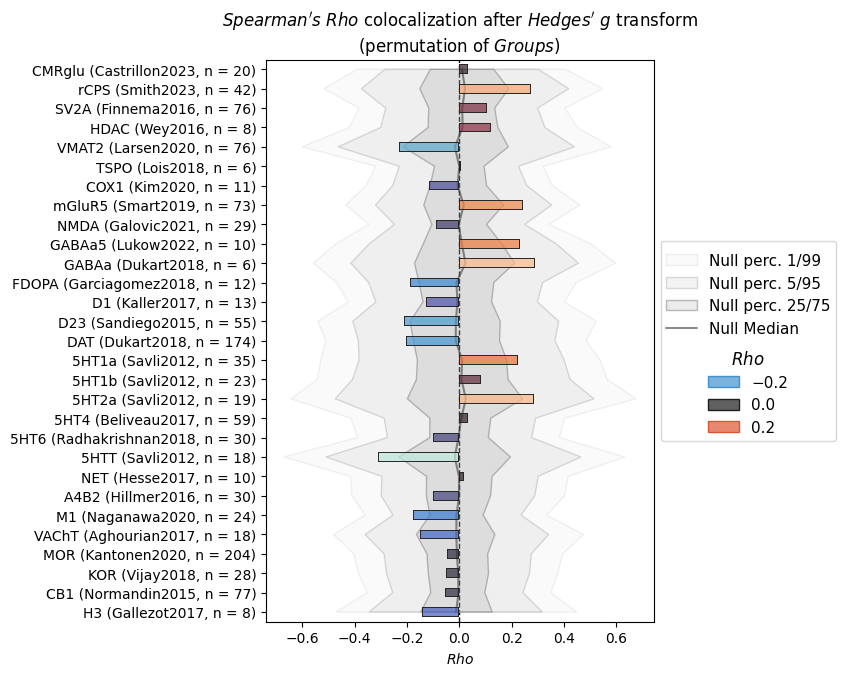

INFO | 23/04/26 15:34:48 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 
INFO | 23/04/26 15:34:48 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 
INFO | 23/04/26 15:34:48 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | meffgalwey | False       | hedges(a,b) | 


In [32]:
# run
colocs_cxsc, pvalues_cxsc, qvalues_cxsc, nsp_object_cxsc = group_comparison(
    y=df_cortexsubcortex, # sample data
    x="pet", # reference data. NOTE: if a string is passed, NiSpace loads the reference data internally
    parcellation="DesikanAseg", # parcellation. NOTE: NiSpace can combine any cortical with any subcortical parcellation
    design=design, # group membership
    comparison_method="hedges(a,b)", # effect size 
    colocalization_method="spearman", # spearman correlation btw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=True,
    seed=42
)

INFO | 23/04/26 15:34:48 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/04/26 15:34:50 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 23/04/26 15:34:50 | nispace: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05
INFO | 23/04/26 15:34:50 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/04/26 15:34:51 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 23/04/26 15:34:51 | nispace: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


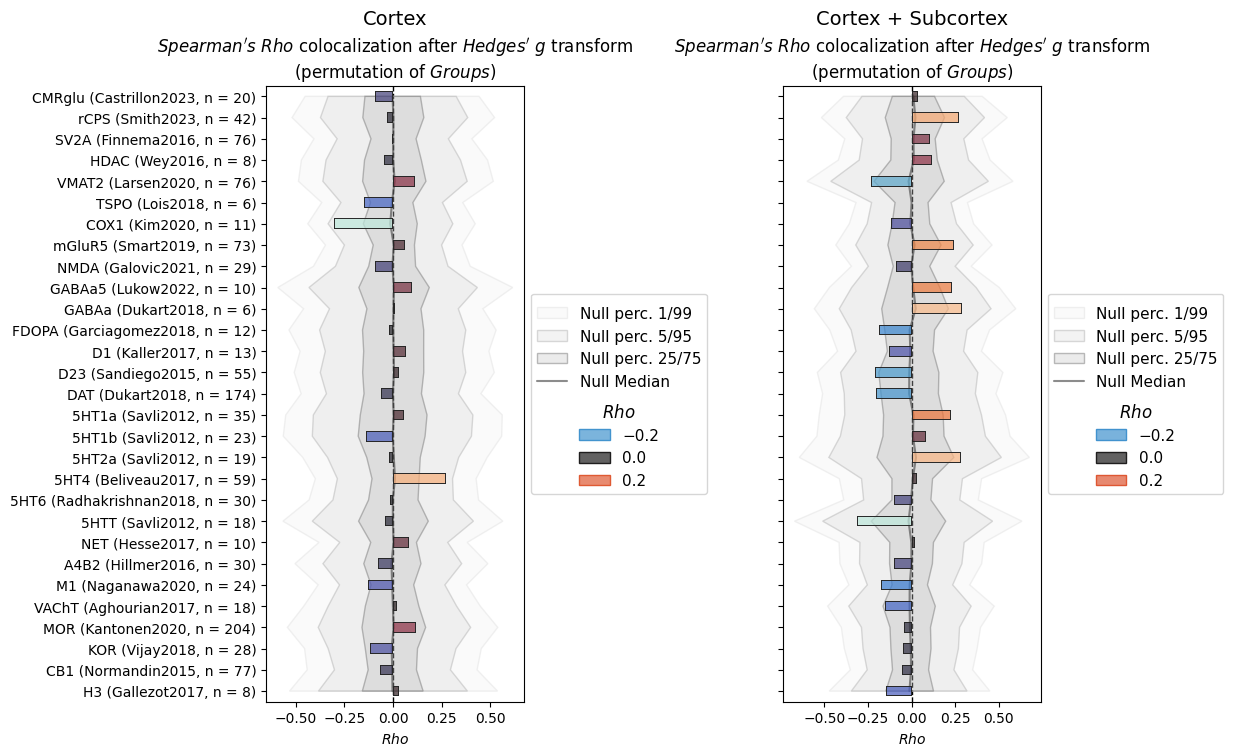

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8), gridspec_kw={"wspace": 1})

nsp_object.plot(fig=fig, ax=axes[0], show=False)
nsp_object_cxsc.plot(fig=fig, ax=axes[1], show=False, plot_kwargs={"scatters": {"size": 7}}, )
axes[0].annotate(xy=(0.5, 1.1), xycoords="axes fraction", ha="center", size=14, text="Cortex")
axes[1].annotate(xy=(0.5, 1.1), xycoords="axes fraction", ha="center", size=14, text="Cortex + Subcortex")
axes[1].set_yticklabels([])
fig.savefig(Path.cwd() / "freesurfer_coloc.png", dpi=300, bbox_inches="tight")